In [12]:
from langgraph.graph import StateGraph,START,END
import os
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict,List
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_community.tools.tavily_search import TavilySearchResults

In [2]:
load_dotenv()

True

In [30]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
llm = ChatOpenAI(
    model="openai/gpt-oss-120b:free",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

In [4]:
docs=(
    PyPDFLoader("../Document/book1.pdf").load()+
    PyPDFLoader("../Document/book2.pdf").load()+
    PyPDFLoader("../Document/book3.pdf").load()
)

In [9]:
splitters=RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150)

chunks=splitters.split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [13]:
from langchain_huggingface import HuggingFaceEmbeddings


embedding=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vectorstore=FAISS.from_documents(chunks,embedding)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3133.30it/s]


In [31]:
retriever=vectorstore.as_retriever(search_type='similarity',search_kwargs={'k':2})

In [32]:
upper_th=0.7
lower_th=0.3

In [33]:
class State(TypedDict):
    que: str
    docs: List[Document]

    good_docs:List[Document]
    verdict:str
    reason:str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_docs:List[Document]

    answer: str

In [34]:
def retrieve(state: State) -> State:
    q = state["que"]
    return {"docs": retriever.invoke(q)}

In [35]:
class DocEvalScore(BaseModel):
    score:float
    reason:str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain=doc_eval_prompt|llm.with_structured_output(DocEvalScore)


In [36]:
def eval_each_doc(state:State)->State:
    q=state['que']
    scores:List[float]=[]
    reasons:List[str]=[]
    good:List[Document]=[]

    for d in state['docs']:
        out=doc_eval_chain.invoke({"question":q,"chunk":d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        if out.score>lower_th:
            good.append(d)
    
    if any(s>upper_th for s in scores):
        return{
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {upper_th}.",
        }
    
    if len(scores)>0 and all(s<lower_th for s in scores):
        why="No chunk was sufficient."
        return{
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {lower_th}. {why}",
        }
    
    why="Mixed relevence signals."
    return{
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {upper_th}, but not all were < {lower_th}. {why}",
    }

In [37]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------

def decompose_to_sentence(text:str)->List[str]:
    text=re.sub(r"\s+"," ",text).strip()
    sentence=re.split(r"(?<=[.!?])\s+",text)
    return [s.strip() for s in sentence if len(s.strip())>20]

# -----------------------------
# FILTER (LLM judge)
# -----------------------------

class KeepOrDrop(BaseModel):
    keep:bool

filter_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        (
            "human", "Question: {question}\n\nSentence:\n{sentence}"
        )
    ]
)

filter_chain=filter_prompt|llm.with_structured_output(KeepOrDrop)

In [38]:
def refine(state:State)->State:
    q=state['que']

    if state.get("verdict")=="CORRECT":
        context="\n\n".join(d.page_content for d in state["good_docs"]).strip()
    else:
        context="\n\n".join(d.page_content for d in state["web_docs"]).strip()

    
    strips=decompose_to_sentence(context)

    kept:List[str]=[]

    for s in strips:
        if filter_chain.invoke({"question":q,"sentence":s}).keep:
            kept.append(s)
    
    redefined_context="\n".join(kept).strip()

    return{
        "strips":strips,
        "kept_strips":kept,
        "refined_context":redefined_context,
    }

In [39]:
tavily=TavilySearchResults(max_results=5)

def web_search(state:State)->State:
    q=state['que']
    result=tavily.invoke({"query":q})

    web_docs=[]

    for r in result or []:
        title=r.get("title","")
        url=r.get("url","")
        content=r.get("content","") or r.get("snippet","")

        text=f"TITLE:{title}\n URL:{url}\n CONTENT:{content}"

        web_docs.append(Document(page_content=text,metadata={"url":url,"title":title}))

    return{
        "web_docs":web_docs
    }

In [40]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state:State)->State:
    out=(answer_prompt|llm).invoke({
        "question": state["que"], "refined_context": state['refined_context']
    })
    return {"answer": out.content}

In [41]:
def ambiguous(state:State)->State:
    return{
        "answer":f"AMBIGIOUS: {state['reason']}"
    }

In [42]:
def route(state:State)->str:
    if state['verdict']=="CORRECT":
        return "refine"
    elif state['verdict']=="INCORRECT":
        return "web_search"
    else:
        return "ambiguous"


In [43]:
graph=StateGraph(State)

graph.add_node("Retrive",retrieve)
graph.add_node("Evaluate",eval_each_doc)

graph.add_node("Ambiguous",ambiguous)
graph.add_node("Web Search",web_search)
graph.add_node("Refine",refine)
graph.add_node("Generate",generate)

graph.add_edge(START,"Retrive")
graph.add_edge("Retrive","Evaluate")
graph.add_conditional_edges(
    "Evaluate",
    route,
    {
        "refine":"Refine",
        "web_search":"Web Search",
        "ambiguous":"Ambiguous",
    }
)
graph.add_edge("Web Search","Refine")

graph.add_edge("Ambiguous",END)
graph.add_edge("Refine","Generate")
graph.add_edge("Generate",END)

In [44]:
app=graph.compile()

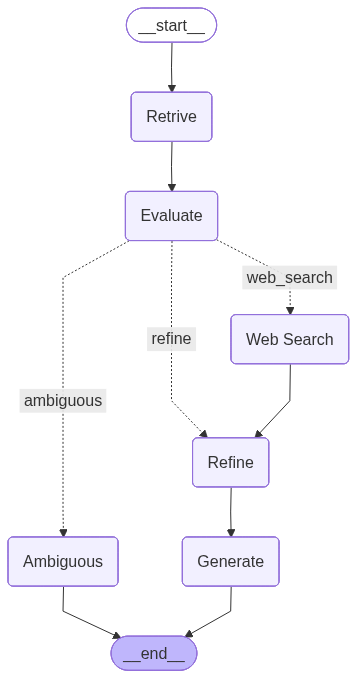

In [45]:
app

In [46]:
res = app.invoke(
    {
        "que": "AI news from the last month",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],
        "answer": "",
    }
)


# res = app.invoke(
#     {
#         "question": "AI news from the last month",
#         "docs": [],
#         "good_docs": [],
#         "verdict": "",
#         "reason": "",
#         "strips": [],
#         "kept_strips": [],
#         "refined_context": "",
#         "web_docs": [],
#         "answer": "",
#     }
# )



print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

TypeError: 'NoneType' object is not iterable

In [ ]:
print(res["good_docs"])